In [21]:
# Logistic Regression on Lung Cancer Dataset 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)


In [24]:
# Load & Prepare 
df = pd.read_csv("LungCancer.csv")

In [36]:
import pandas as pd

df = pd.read_csv("LungCancer.csv")
print(df.dtypes)

id                      int64
age                   float64
gender                 object
country                object
diagnosis_date         object
cancer_stage           object
family_history         object
smoking_status         object
bmi                   float64
cholesterol_level       int64
hypertension            int64
asthma                  int64
cirrhosis               int64
other_cancer            int64
treatment_type         object
end_treatment_date     object
survived                int64
dtype: object


In [26]:
# Drop non-predictive columns
drop_cols = ["id", "country", "diagnosis_date", "end_treatment_date"]
df = df.drop(columns=drop_cols, errors="ignore")
df["survived"] = df["survived"].astype(int)

In [27]:
#Train/test split
X = df.drop(columns=["survived"])
y = df["survived"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [46]:
#Features by type 
numeric_features = ["age", "bmi", "cholesterol_level"]
binary_features = ["hypertension", "asthma", "cirrhosis", "other_cancer"]
categorical_features = ["gender", "cancer_stage", "family_history", "smoking_status", "treatment_type"]


In [47]:
# Preprocessing 
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])


In [48]:
# Combine
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("bin", binary_transformer, binary_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [57]:
#Logistic Regression 
clf = Pipeline(steps=[("preprocess", preprocess),
                     ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])

clf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi',
                                                   'cholesterol_level']),
                                                 ('bin',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['hypertension', 'asthma',
                                                   'cirrhosis',
                                                   'other_cancer']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'cancer_stage',
                                                   'family_history',
                                                   'smoking_status',
                                                   'treatment_type'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [50]:
# Predictions
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

In [51]:
#Metrics 
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print("==== Logistic Regression Performance ====")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC AUC:   {auc:.4f}\n")

==== Logistic Regression Performance ====
Accuracy:  0.4816
Precision: 0.2201
Recall:    0.5325
F1 Score:  0.3115
ROC AUC:   0.5011



In [52]:
# Classification report (per class metrics)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.47      0.58    138799
           1       0.22      0.53      0.31     39201

    accuracy                           0.48    178000
   macro avg       0.50      0.50      0.45    178000
weighted avg       0.66      0.48      0.52    178000



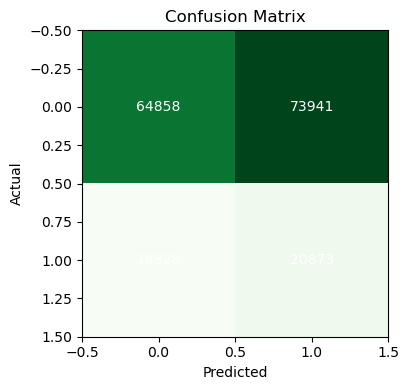

In [54]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest", cmap="Greens")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center", color="white")
plt.tight_layout()
plt.show()

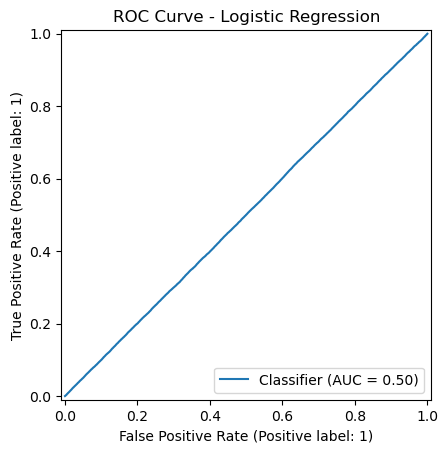

In [55]:
# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - Logistic Regression")
plt.show()

In [56]:
#Feature Importance (odds ratios) 
# Extract feature names
ct = clf.named_steps["preprocess"]
ohe = ct.named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(categorical_features)

feature_names = np.concatenate([
    np.array(numeric_features),
    np.array(binary_int_features),
    cat_names
])

coefs = clf.named_steps["model"].coef_.flatten()
odds_ratios = np.exp(coefs)

feat_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "odds_ratio": odds_ratios
}).sort_values("coefficient", ascending=False)

print("\n==== Top 10 Positive Predictors of Survival ====")
print(feat_df.head(10).to_string(index=False))

print("\n==== Top 10 Negative Predictors of Survival ====")
print(feat_df.tail(10).to_string(index=False))



==== Top 10 Positive Predictors of Survival ====
                      feature  coefficient  odds_ratio
                    cirrhosis     0.009915    1.009964
       treatment_type_Surgery     0.007671    1.007700
       cancer_stage_Stage III     0.006373    1.006394
        cancer_stage_Stage IV     0.005403    1.005418
        cancer_stage_Stage II     0.004311    1.004320
           family_history_Yes     0.004208    1.004217
                  gender_Male     0.004074    1.004083
                          age     0.003673    1.003680
smoking_status_Current Smoker     0.002548    1.002551
smoking_status_Passive Smoker     0.002406    1.002409

==== Top 10 Negative Predictors of Survival ====
                     feature  coefficient  odds_ratio
    treatment_type_Radiation     0.001237    1.001237
                         bmi     0.000557    1.000558
                hypertension    -0.000775    0.999225
               gender_Female    -0.003063    0.996942
           family_history